# CBA 2026 SHAP Analysis — Target-Level Attribution × Performance (publication-quality rebuild)

Selected +CNV MOSA run: `20260505_131645`.

This notebook is a publication-quality rebuild of the original `cba2026/02_target_level_shap_performance.ipynb`. Selected TabPFN performance (`expanded` × `mosa_all`) is joined to a per-target SHAP composition profile and used as input for downstream diagnostic figures. All plotting flows through `_shap_analysis.py` so the visual style stays consistent with notebook 01.

**Coverage**
- **Fig 4 — Performance vs SHAP profile** (replaces original Fig 5): four-panel diagnostic using `gridspec` with proper sample-size legend and family-stratified dominant-omic boxplot.
- **Fig 5 — Selected CRISPR target top features** (replaces original Fig 6): MDM2 / MDM4 / top-Δr backfill panels with consistent styling and per-panel ×10⁻³ axis. Targets unavailable in the SHAP export are noted explicitly.
- **Fig 6 — Selected CRISPR target omic composition** (replaces original Fig 7): magma heatmap with annotated cell values and luminance-aware text colour.
- **Fig 7 — CNV gain volcano** (new): ΔPearson r vs CNV share of top-200 SHAP, with leader-line callouts for the top-10 gainers per family.
- Tables: per-target summary, top gain / loss vs RF baseline, high-CNV-share targets.


In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd()))
import _shap_analysis as shap_an

print(f"ROOT     = {shap_an.ROOT}")
print(f"FIG_DIR  = {shap_an.FIG_DIR}")

ROOT     = /mnt/scratch/scai/PhenPredCCMA
FIG_DIR  = /mnt/scratch/scai/PhenPredCCMA/reports/cba2026_claude/shap_analysis/20260505_131645


## Build the analysis frame

`load_shap_tables()` and `load_performance()` read all required inputs. `assemble_analysis_table` produces one row per (family, target) with: top200-share per omic layer, dominant-omic flag, omic-entropy, copy-number feature count, selected TabPFN test-set Pearson r and the Δr versus the random-forest `overlap × original` baseline.


In [2]:
tables = shap_an.load_shap_tables()
performance = shap_an.load_performance()
analysis = shap_an.assemble_analysis_table(tables, performance)

missing_perf = analysis["test_pearsonr_tabpfn"].isna().sum()
if missing_perf:
    print(f"Warning: {missing_perf} SHAP targets did not match per-target performance rows.")

analysis.groupby("target_label")[[
    "test_pearsonr_tabpfn",
    "delta_pearsonr_vs_rf",
    "share_copynumber",
    "omic_entropy",
]].describe().round(3)

test_pearsonr_tabpfn                                            \
                             count   mean    std    min    25%    50%    75%   
target_label                                                                   
CRISPR-Cas9                  500.0  0.212  0.243 -0.624  0.049  0.219  0.389   
Drug response                500.0  0.319  0.249 -0.377  0.144  0.325  0.505   

                     delta_pearsonr_vs_rf         ... share_copynumber         \
                 max                count   mean  ...              75%    max   
target_label                                      ...                           
CRISPR-Cas9    0.844                500.0  0.061  ...              0.0  0.247   
Drug response  0.861                500.0  0.085  ...              0.0  0.008   

              omic_entropy                                                   
                     count   mean    std    min    25%    50%    75%    max  
target_label                                                                 
CRISPR-Cas9          500.0  0.499  0.105  0.141  0.447  0.510  0.563  0.797  
Drug response        500.0  0.543  0.085  0.162  0.506  0.556  0.599  0.726  

[2 rows x 32 columns]

## Figure 4 — Performance vs SHAP profile (4-panel diagnostic)

- **(a)** Per-family Pearson r distribution (step histogram, density-normalised).
- **(b)** Copy-number share of top-200 SHAP vs Pearson r — does CNV attribution track better-predicted targets?
- **(c)** Omic entropy of top-200 SHAP vs Δr versus RF — do well-distributed attributions correspond to the +CNV-MOSA gain?
- **(d)** Pearson r grouped by the dominant omic layer of each target's top-200 SHAP, family-stratified boxplots.

All scatter panels are rasterised so the saved PDF stays small (text remains vector and editable).


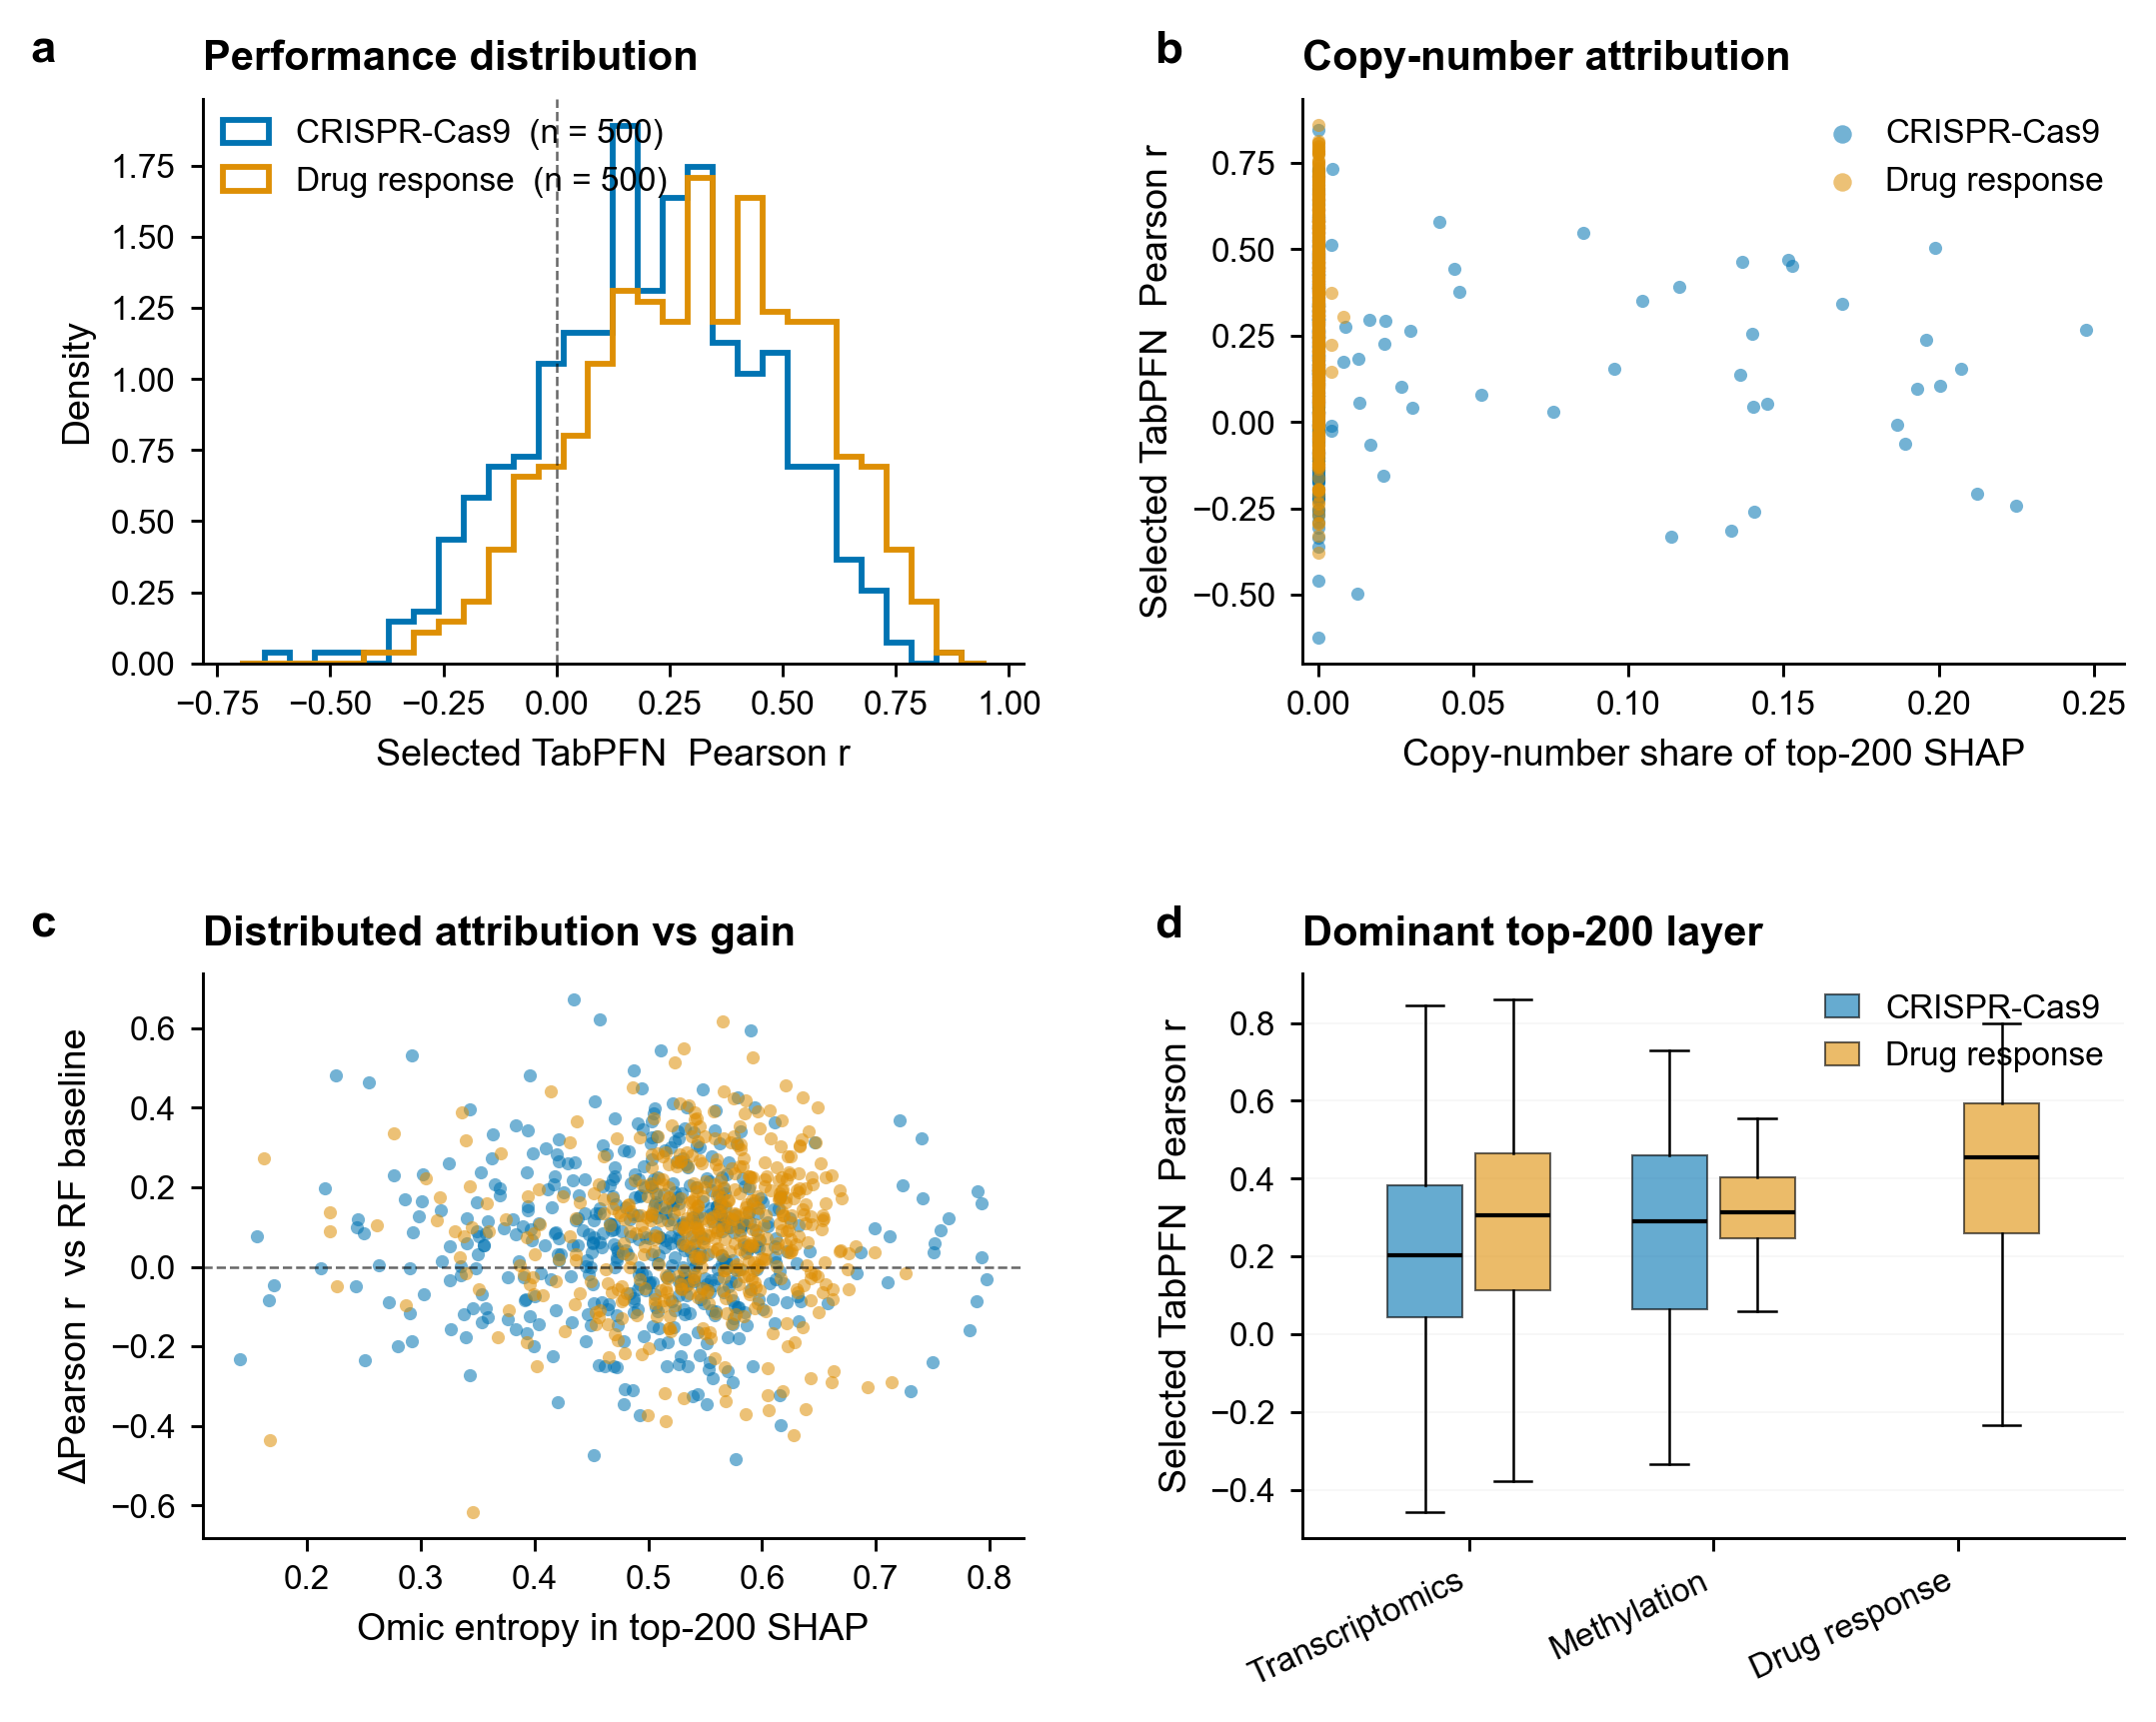

In [3]:
fig4_pdf = shap_an.fig4_performance_vs_profile(analysis)
display(Image(filename=str(fig4_pdf.with_suffix(".png")), embed=True))

## Figure 5 — Selected CRISPR target top features

Bar plots of the top-18 SHAP features per requested CRISPR target. TP53 is requested but **not** present in the top-features SHAP export; the function backfills any unavailable slot with the highest-Δr CRISPR target so the panel layout stays balanced and biologically interpretable. Each panel uses an independent x-axis (per-target SHAP scales differ by ≈10×); the panel title carries Pearson r and Δr.


Requested targets unavailable in SHAP export: ['TP53']
Targets actually plotted: ['MDM2', 'MDM4', 'PSMA2']


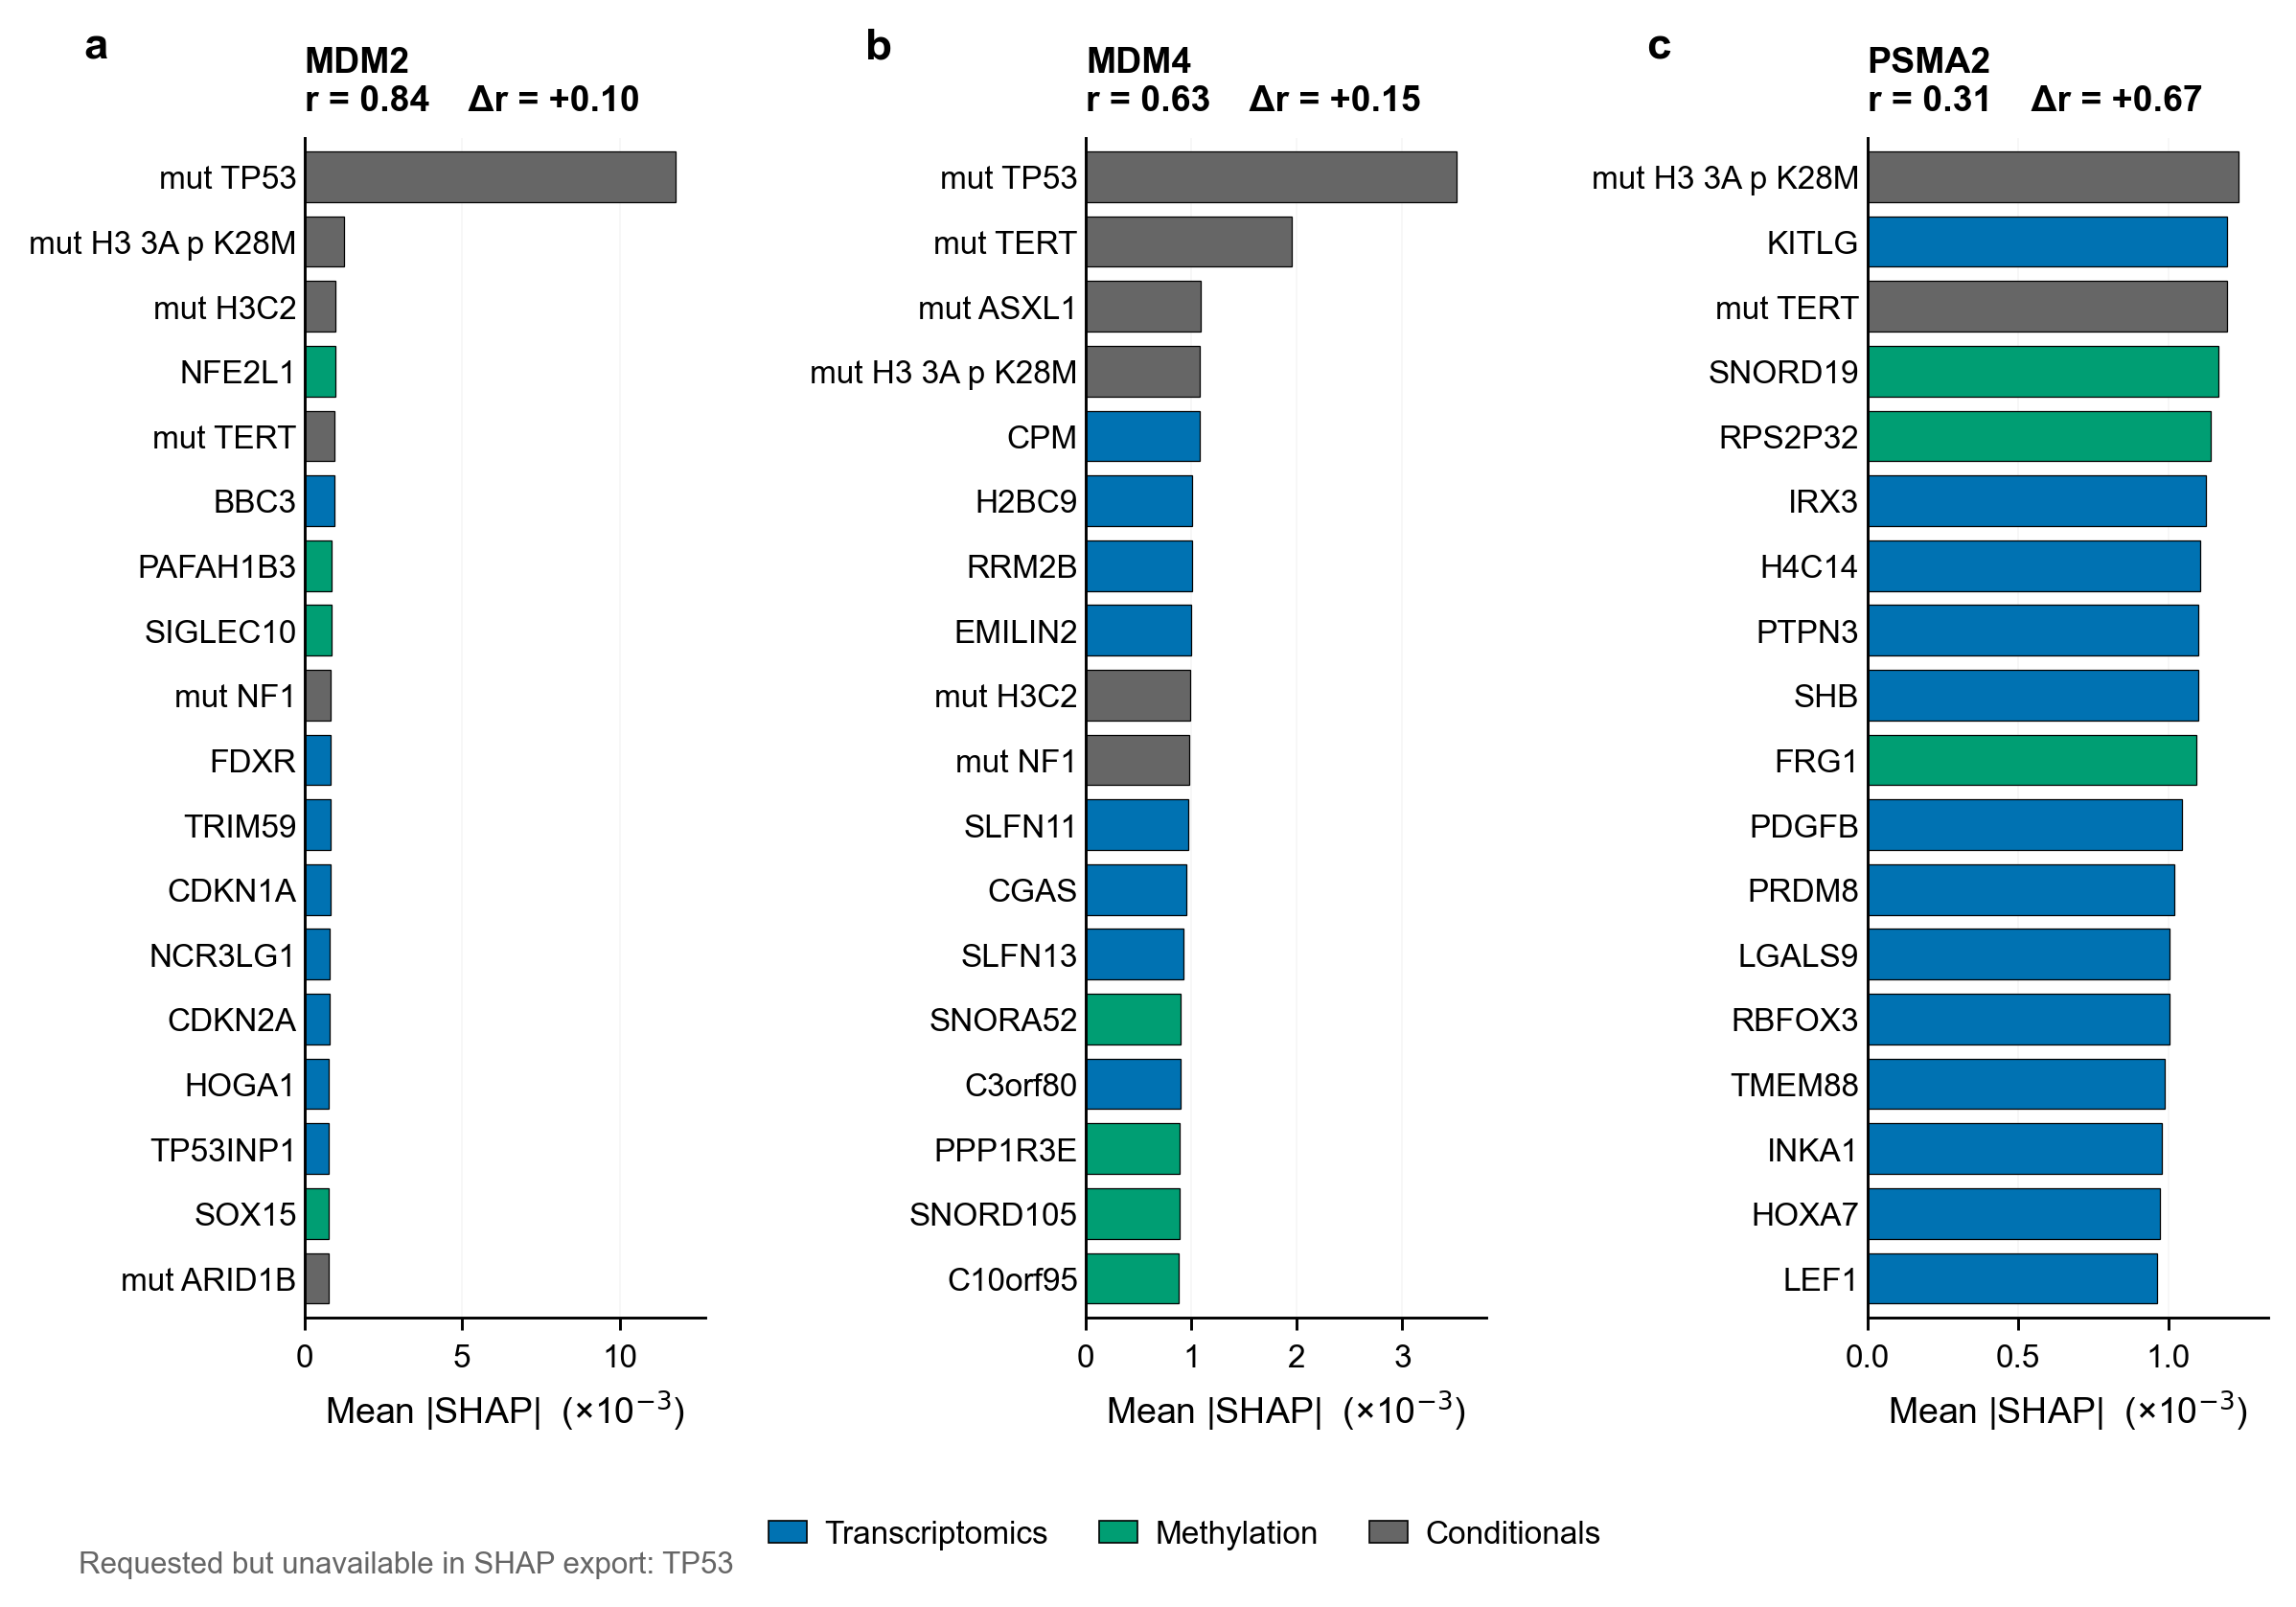

In [4]:
fig5_pdf, plotted_targets, missing_targets = shap_an.fig5_selected_crispr_top_features(
    tables, analysis, requested=("TP53", "MDM2", "MDM4"), top_n=18,
)
if missing_targets:
    print(f"Requested targets unavailable in SHAP export: {missing_targets}")
print(f"Targets actually plotted: {plotted_targets}")
display(Image(filename=str(fig5_pdf.with_suffix(".png")), embed=True))

## Figure 6 — Selected CRISPR target omic composition

Heatmap of top-200 SHAP share by omic layer for the same selected targets, with annotated cell values. Magma colormap is luminance-aware, so the cell-value text colour is chosen automatically to stay legible against the background.


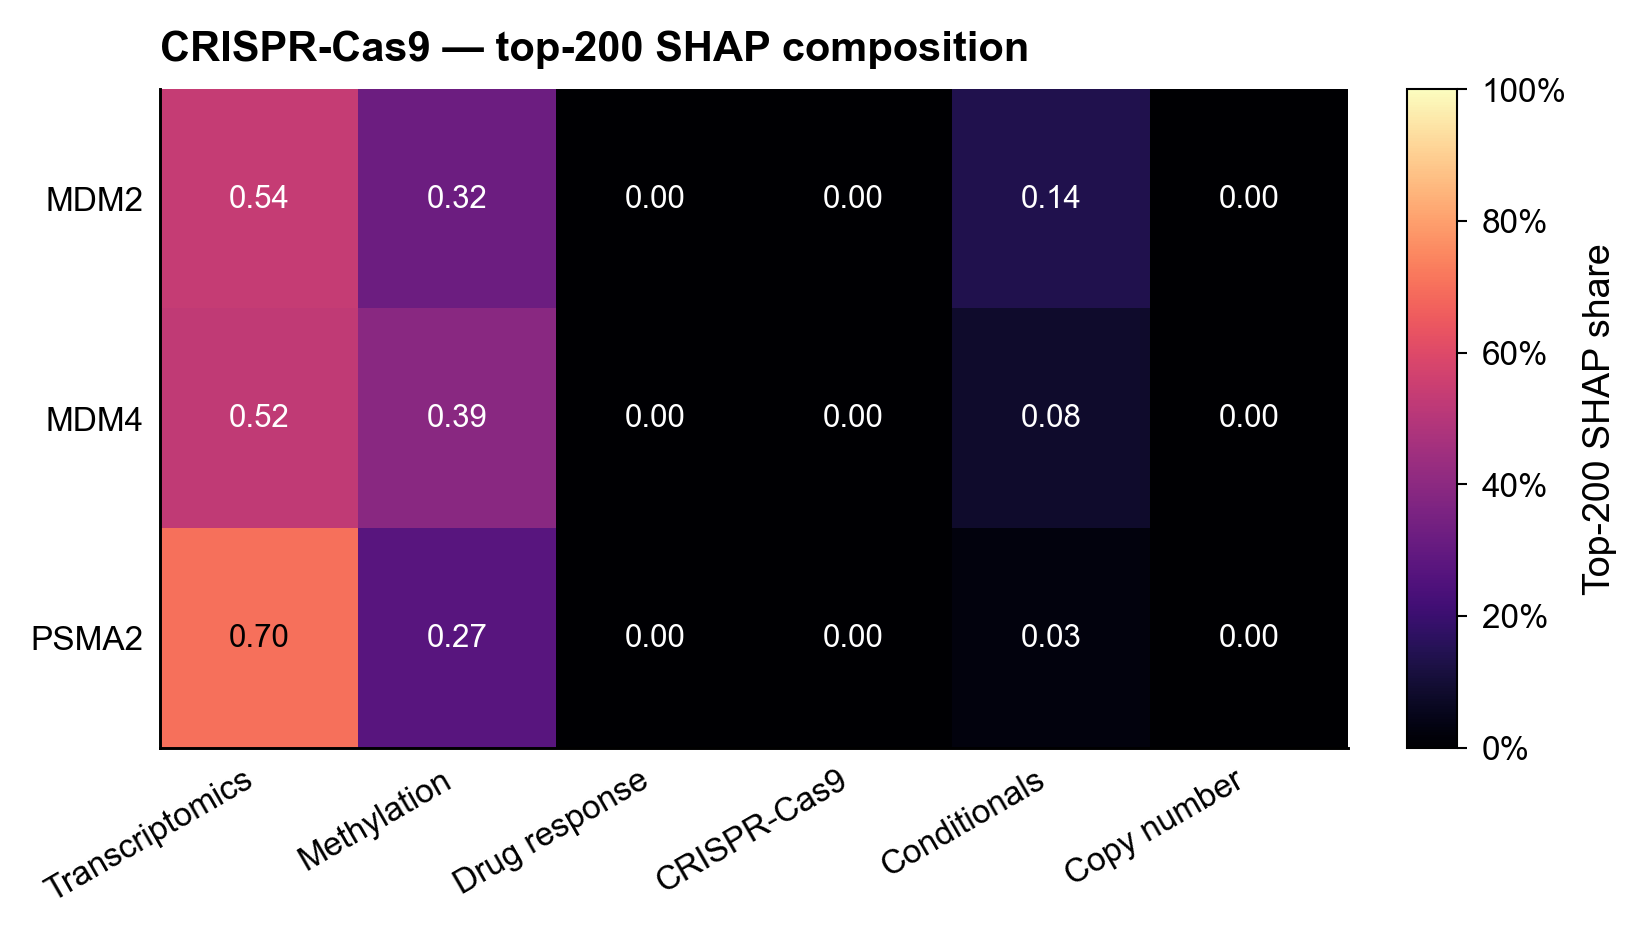

In [5]:
fig6_pdf = shap_an.fig6_selected_crispr_omic_heatmap(analysis, targets=plotted_targets)
display(Image(filename=str(fig6_pdf.with_suffix(".png")), embed=True))

## Figure 7 — CNV gain volcano (new)

ΔPearson r versus copy-number share of top-200 SHAP, per family. The top-10 Δr targets per family are outlined in brick red and labelled in a callout column on the right of each panel; leader lines connect markers to labels so labels never collide with markers or with each other. This figure highlights the targets where adding CNV both produced a measurable performance lift over the RF baseline and shifted the SHAP profile towards CNV.


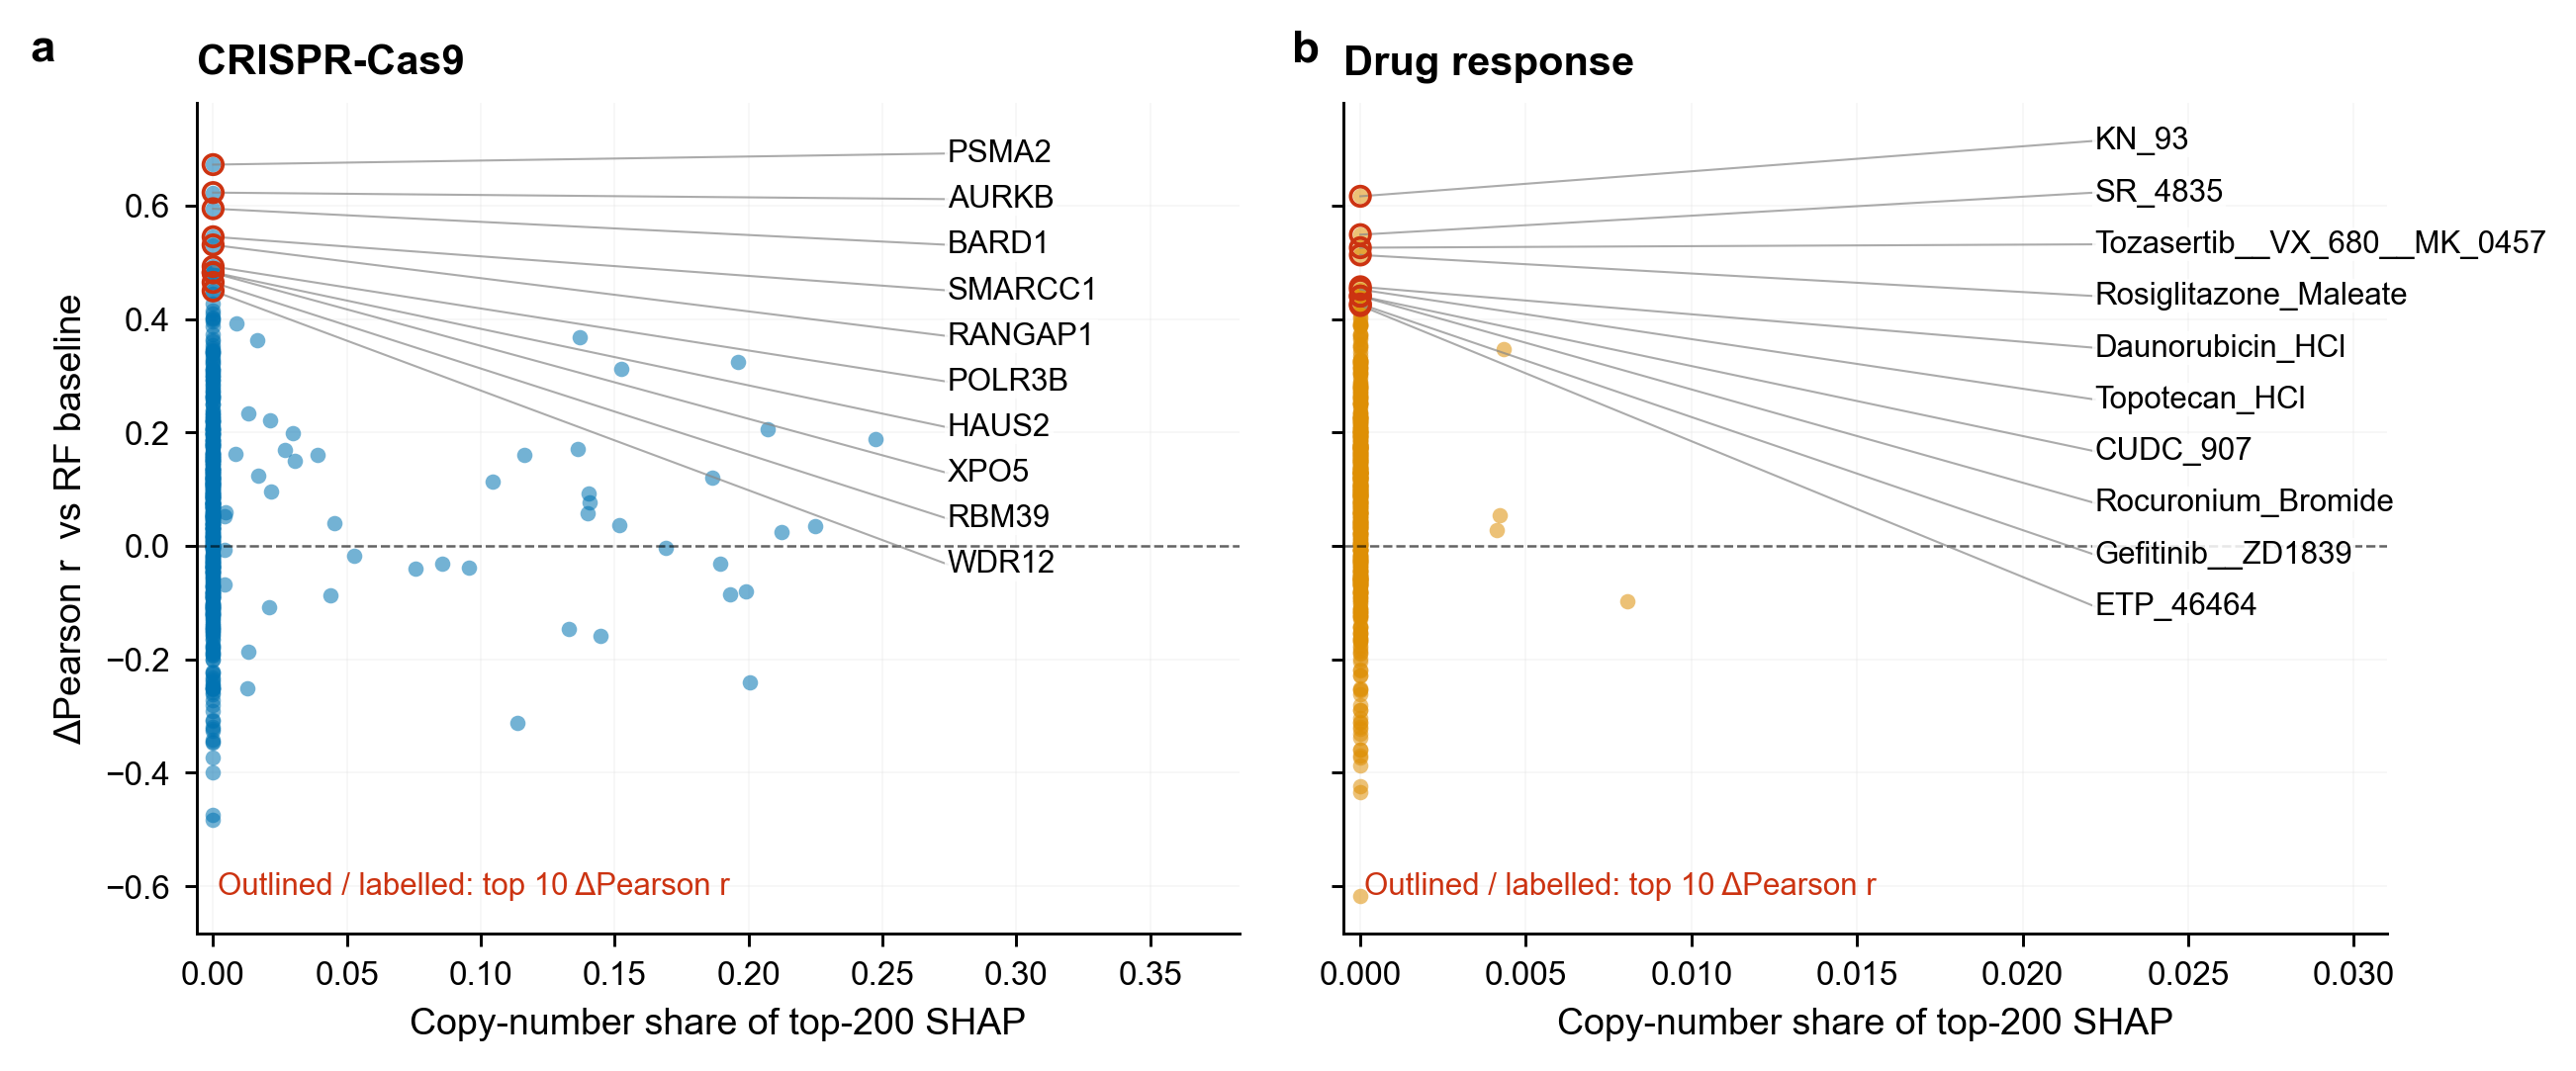

In [6]:
fig7_pdf = shap_an.fig7_cnv_gain_volcano(analysis)
display(Image(filename=str(fig7_pdf.with_suffix(".png")), embed=True))

## Follow-up tables

Per-target summary plus winners/losers vs the RF baseline and the most CNV-attributed targets per family.


In [7]:
table_paths = shap_an.write_tables(tables, analysis)
for name, path in table_paths.items():
    print(f"{name}: {path.relative_to(shap_an.ROOT)}")

table_global_copynumber_feature_ranking: reports/cba2026_claude/shap_analysis/20260505_131645/table_global_copynumber_feature_ranking.csv
table_copynumber_feature_frequency_top200: reports/cba2026_claude/shap_analysis/20260505_131645/table_copynumber_feature_frequency_top200.csv
table_target_copynumber_share_top200: reports/cba2026_claude/shap_analysis/20260505_131645/table_target_copynumber_share_top200.csv
target_level_shap_performance_summary: reports/cba2026_claude/shap_analysis/20260505_131645/target_level_shap_performance_summary.csv
targets_high_copynumber_shap_share: reports/cba2026_claude/shap_analysis/20260505_131645/targets_high_copynumber_shap_share.csv
targets_top_gain_loss_vs_rf_baseline: reports/cba2026_claude/shap_analysis/20260505_131645/targets_top_gain_loss_vs_rf_baseline.csv


In [8]:
gains = pd.read_csv(table_paths["targets_top_gain_loss_vs_rf_baseline"])
gains[[
    "direction", "target_label", "target_name", "test_pearsonr_tabpfn",
    "test_pearsonr_rf_baseline", "delta_pearsonr_vs_rf",
    "dominant_omic", "share_copynumber",
]].head(20)

,direction,target_label,target_name,test_pearsonr_tabpfn,test_pearsonr_rf_baseline,delta_pearsonr_vs_rf,dominant_omic,share_copynumber
0,top_gain,CRISPR-Cas9,PSMA2,0.314911,-0.357518,0.672429,transcriptomics,0.000000
1,top_gain,CRISPR-Cas9,AURKB,0.319008,-0.304089,0.623096,transcriptomics,0.000000
2,top_gain,CRISPR-Cas9,BARD1,0.412425,-0.182286,0.594710,transcriptomics,0.000000
3,top_gain,CRISPR-Cas9,SMARCC1,0.710561,0.165370,0.545191,transcriptomics,0.000000
4,top_gain,CRISPR-Cas9,RANGAP1,0.437430,-0.093345,0.530775,transcriptomics,0.000000
5,top_gain,CRISPR-Cas9,POLR3B,0.505672,0.012839,0.492832,transcriptomics,0.000000
6,top_gain,CRISPR-Cas9,HAUS2,0.075926,-0.406589,0.482514,transcriptomics,0.000000
7,top_gain,CRISPR-Cas9,XPO5,0.456206,-0.025307,0.481513,transcriptomics,0.000000
8,top_gain,CRISPR-Cas9,RBM39,0.421824,-0.042943,0.464767,transcriptomics,0.000000
9,top_gain,CRISPR-Cas9,WDR12,0.643684,0.193867,0.449817,transcriptomics,0.000000


In [9]:
cnv_top = pd.read_csv(table_paths["targets_high_copynumber_shap_share"])
cnv_top[[
    "target_label", "target_name", "share_copynumber", "copynumber_n_top200",
    "test_pearsonr_tabpfn", "delta_pearsonr_vs_rf", "dominant_omic",
]].head(20)

,target_label,target_name,share_copynumber,copynumber_n_top200,test_pearsonr_tabpfn,delta_pearsonr_vs_rf,dominant_omic
0,CRISPR-Cas9,ANLN,0.247354,38,0.265618,0.188888,transcriptomics
1,CRISPR-Cas9,ANAPC5,0.224848,38,-0.243278,0.035558,transcriptomics
2,CRISPR-Cas9,PFDN6,0.212307,38,-0.206428,0.024336,transcriptomics
3,CRISPR-Cas9,PLRG1,0.207220,38,0.155346,0.206038,transcriptomics
4,CRISPR-Cas9,RACGAP1,0.200334,38,0.104431,-0.240043,transcriptomics
5,CRISPR-Cas9,EFTUD2,0.198889,38,0.504903,-0.080762,transcriptomics
6,CRISPR-Cas9,KCMF1,0.195894,38,0.236675,0.323865,transcriptomics
7,CRISPR-Cas9,MED14,0.192925,38,0.096358,-0.086054,transcriptomics
8,CRISPR-Cas9,PSMD11,0.189295,38,-0.063394,-0.030846,transcriptomics
9,CRISPR-Cas9,NCL,0.186445,38,-0.008340,0.120833,transcriptomics


## Output files


In [10]:
for path in sorted(shap_an.FIG_DIR.glob("fig*")):
    print(path.relative_to(shap_an.ROOT))
for path in sorted(shap_an.FIG_DIR.glob("*target*csv")):
    print(path.relative_to(shap_an.ROOT))

reports/cba2026_claude/shap_analysis/20260505_131645/fig1_global_landscape.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig1_global_landscape.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig2_global_feature_heatmap.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig2_global_feature_heatmap.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig3_target_omic_composition.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig3_target_omic_composition.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig4_performance_vs_profile.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig4_performance_vs_profile.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig5_selected_crispr_top_features.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/fig5_selected_crispr_top_features.png
reports/cba2026_claude/shap_analysis/20260505_131645/fig6_selected_crispr_omic_composition.pdf
reports/cba2026_claude/shap_analysis/20260505_131645/